In [1]:
import sys, os
from utils import * 


In [2]:
import joblib

DATASET_NAME, X_train, X_test, y_train, y_test = joblib.load("IEEE_data.pkl")
y_test = y_test.values.ravel()

MODEL_NAME = "GMM_EM"
DE_LONG_RESULTS = "IEEE_CIS_all_results.pkl"
METRICS = "IEEE_CIS_metrics.pkl"


In [3]:
# ================================================================
# ================================================================
# ================================================================
# ================================================================
# ================================================================
# =================== 5. GMM with EM algorithm ===================
# ================================================================
# ================================================================
# ================================================================
# ================================================================
# ================================================================

In [4]:
# ===================== 5. GMM with EM algorithm =====================
GMM_train_scores, GMM_test_scores, GMM_model = run_gmm(X_train, X_test, n_components=GMM_N_COMPONENTS)


Iteration 0
Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7


In [ ]:
# ===================== Store metrics =====================
GMM_metrics = store_anomaly_metrics(y_true=y_test, scores=-GMM_test_scores, dataset_name=DATASET_NAME, model_name=MODEL_NAME)
display(GMM_metrics)


In [ ]:
# ===================== Plot results =====================
plot_anomaly_roc_pr(y_true=y_test, scores=-GMM_test_scores, dataset_name=DATASET_NAME, model_name=MODEL_NAME)

In [8]:
# ===================== Fit on CV folds =====================
GMM_cv_results = fit_cross_validate(X_train, y_train, X_test, y_test, run_gmm, DATASET_NAME, MODEL_NAME, CV_FOLDS, RANDOM_STATE)


Iteration 0
Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 0
Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 0
Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 0
Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 0
Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7


In [9]:
# ===================== Store CV metrics =====================

GMM_cv_metrics = pd.concat([r["test_metrics"] for r in GMM_cv_results], ignore_index=True)
display(GMM_cv_metrics)



,Model,Data,Precision,Precision_CI,Recall,Recall_CI,F1,F1_CI,ROC_AUC,ROC_AUC_CI,PR_AUC,PR_AUC_CI,Confusion_Matrix,Threshold
0,GMM_EM_Fold1,train_transaction22,0.033864,0.029-0.039,0.048391,0.042-0.055,0.039845,0.035-0.045,0.492371,0.484-0.501,0.033989,0.033-0.035,"[[108269, 5706], [3933, 200]]",33.325681
1,GMM_EM_Fold2,train_transaction22,0.033520,0.029-0.038,0.047907,0.042-0.055,0.039442,0.035-0.045,0.492239,0.484-0.501,0.033972,0.033-0.035,"[[108266, 5709], [3935, 198]]",33.329440
2,GMM_EM_Fold3,train_transaction22,0.033345,0.029-0.038,0.047665,0.042-0.054,0.039239,0.034-0.045,0.492408,0.484-0.501,0.033979,0.033-0.035,"[[108264, 5711], [3936, 197]]",33.313685
3,GMM_EM_Fold4,train_transaction22,0.033864,0.030-0.039,0.048391,0.042-0.055,0.039845,0.035-0.045,0.492407,0.484-0.501,0.033996,0.033-0.036,"[[108269, 5706], [3933, 200]]",33.344566
4,GMM_EM_Fold5,train_transaction22,0.033864,0.029-0.039,0.048391,0.042-0.055,0.039845,0.035-0.045,0.492501,0.484-0.501,0.034002,0.033-0.036,"[[108269, 5706], [3933, 200]]",33.342749


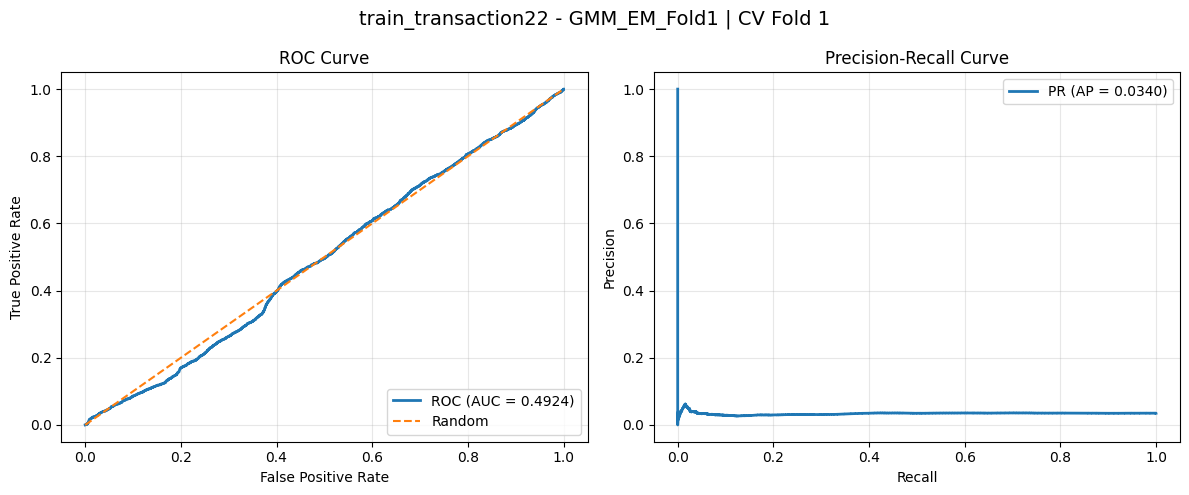

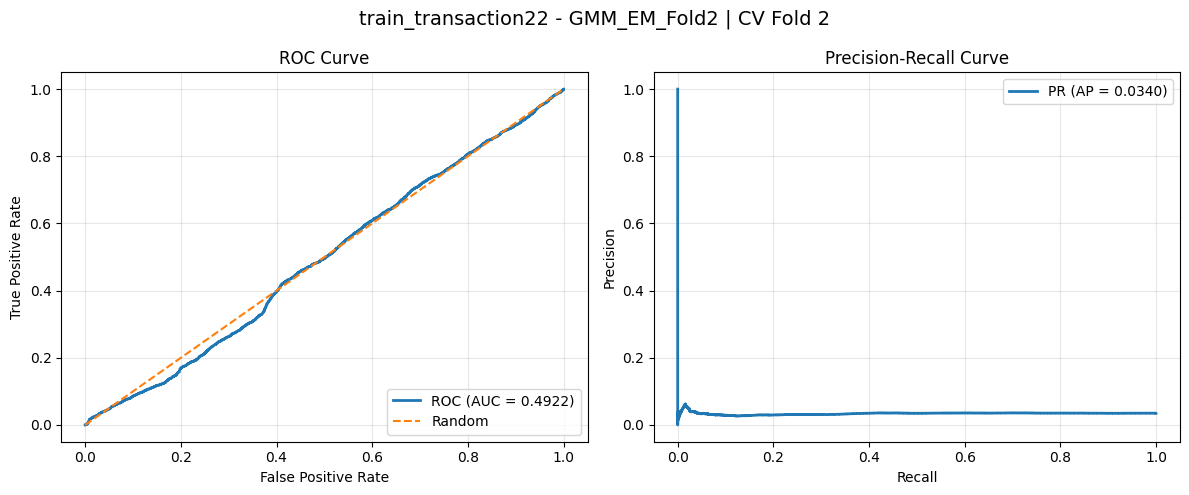

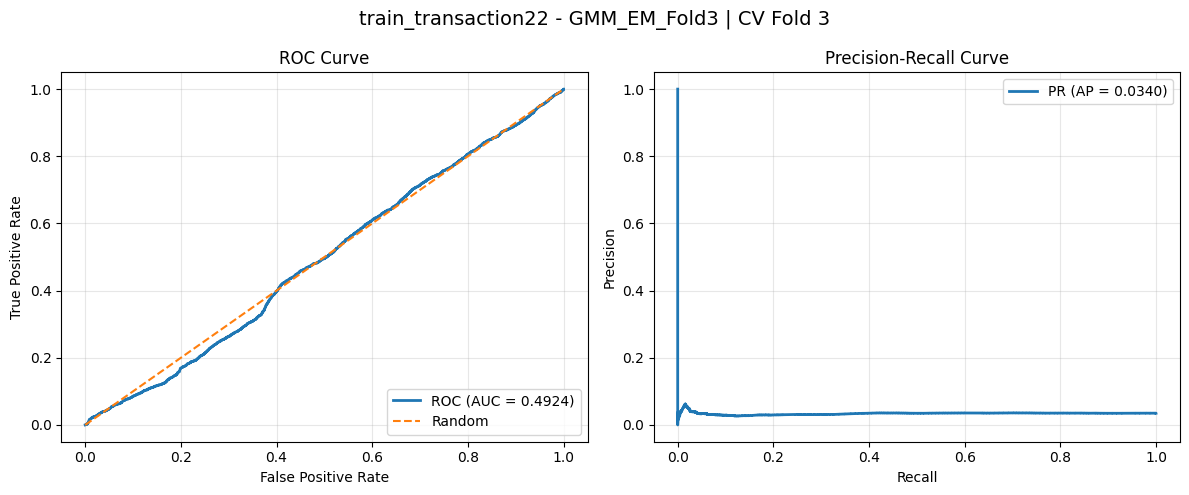

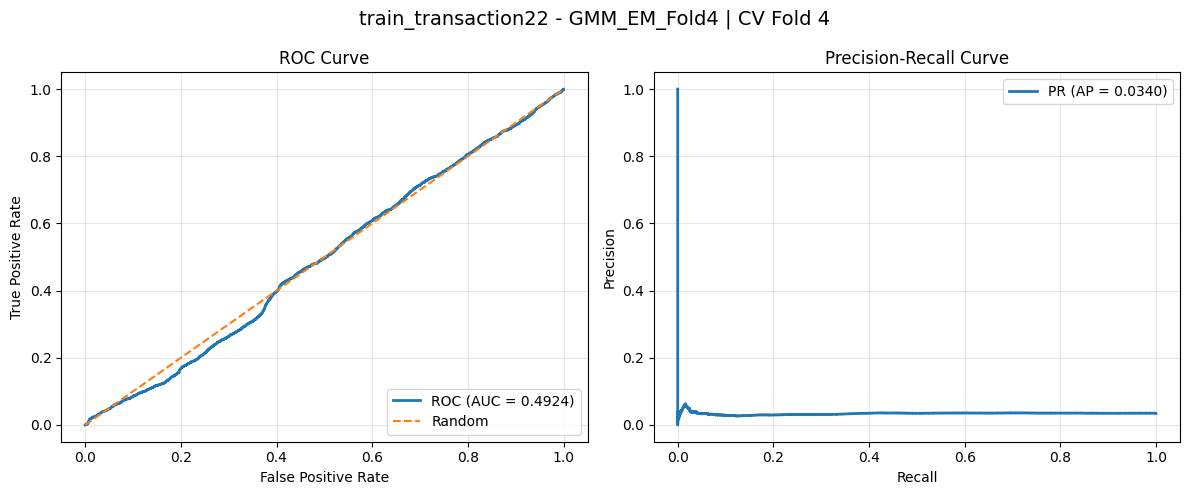

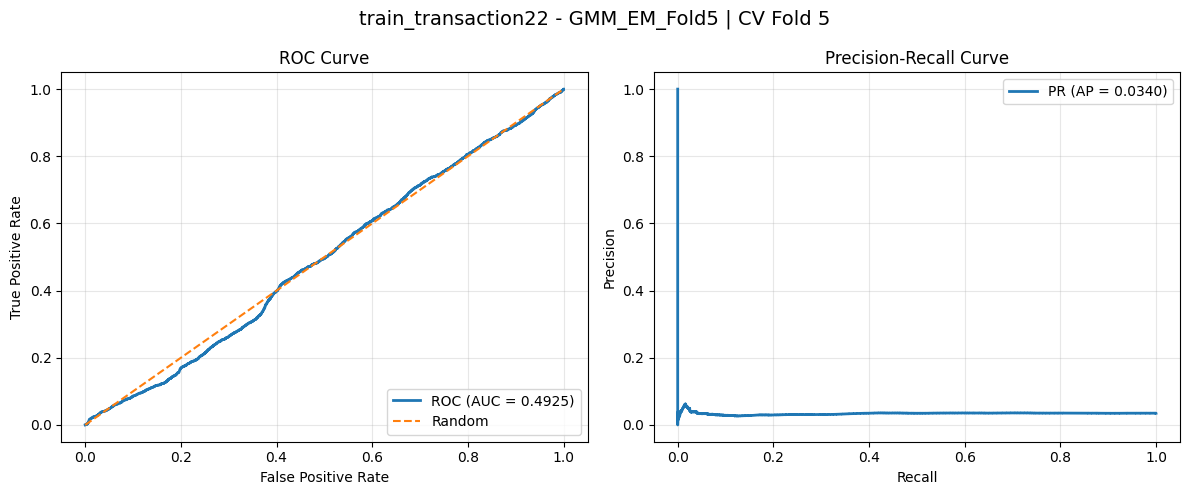

In [10]:
# ===================== Plot CV results =====================

for r in GMM_cv_results:
    plot_anomaly_roc_pr(y_test, r["test_scores"], DATASET_NAME, f"{MODEL_NAME}_Fold{r['fold']}", r["fold"])


In [15]:
if os.path.exists(DE_LONG_RESULTS):
    results = joblib.load(DE_LONG_RESULTS)
else:
    results = {}

results[MODEL_NAME] = {
    "test_scores": -GMM_test_scores,
    "auc": roc_auc_score(y_test, -GMM_test_scores)
}

joblib.dump(results, DE_LONG_RESULTS)

['IEEE_CIS_all_results.pkl']

In [12]:
if os.path.exists(METRICS):
    results = joblib.load(METRICS)
else:
    results = {}

results[MODEL_NAME] = {
    "metrics": GMM_metrics,
    "cv_metrics": GMM_cv_metrics
}

joblib.dump(results, METRICS)

['IEEE_CIS_metrics.pkl']